# Etapa 3: Aplicação de ML e Treinamento de Modelos

**ImunizaData**: segmentação e classificação de risco de baixa cobertura vacinal por município.

## Objetivo e escopo

Este notebook usa o dataset já limpo e cruzado da Etapa 2
(`refined/cobertura_vacinal`) para: (1) segmentar os municípios por
perfil socioeconômico e de cobertura via clusterização (K-Means), e (2)
treinar um classificador de "baixa cobertura" usando características
demográficas, socioeconômicas e geográficas do município.

**Recorte importante**: só temos um ano de dado processado (2025). O
objetivo original do projeto (`docs/entendimento_problema.md`, pergunta
5, e o README) fala em prever risco de baixa cobertura *futura*/"no
próximo ciclo" — isso exigiria treinar com features de um ano para
prever o resultado do ano seguinte. Sem um segundo ano de PNI/IBGE/PIB
processado, um modelo "preditivo de futuro" seria, na prática, treinado
e avaliado no mesmo ano. Por isso este notebook assume um objetivo mais
honesto com os dados disponíveis: **classificar o perfil de risco atual**
dos municípios (modelo transversal, não temporal). Essa limitação e o
caminho para superá-la ficam registrados na seção 9.

> Antes de rodar este notebook: garanta que a Etapa 2 já rodou
> (`notebooks/02_analise_exploratoria.ipynb` ou os comandos do README até
> `build_coverage.py`), e instale as dependências novas desta etapa:
> `pip install -r requirements.txt` (inclui `scikit-learn` e `xgboost`).

Decisões técnicas e de negócio desta etapa (definição do alvo,
algoritmos escolhidos e por quê, estratégia de split, limitações) estão
documentadas em detalhe em
[`docs/decisoes_modelagem.md`](../docs/decisoes_modelagem.md) — este
notebook foca na execução; o documento foca no raciocínio.

In [1]:
import io
import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from botocore.client import Config

from src.config import MINIO_ACCESS_KEY, MINIO_ENDPOINT, MINIO_SECRET_KEY

sns.set_theme(style="whitegrid")

ANO = 2025
BUCKET_REFINED = os.getenv("MINIO_REFINED_BUCKET", "refined")

s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    config=Config(signature_version="s3v4"),
)

key = f"cobertura_vacinal/ano={ANO}/cobertura_municipios.parquet"
obj = s3.get_object(Bucket=BUCKET_REFINED, Key=key)
df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
df.shape


(5571, 10)

## 1. Construção do dataset de features

Partimos das hipóteses registradas ao final do notebook 02 e das
colunas já disponíveis em `refined/cobertura_vacinal`:

- **Fronteira**: a análise exploratória (seção 3 do notebook 02) mostrou
  outliers de cobertura concentrados em municípios de fronteira
  (efeito "caravana da vacina"). Não temos a lista oficial de
  municípios da faixa de fronteira (Lei 6.634/1979) nesta pipeline, então
  aproximamos por UF: os 11 estados que compõem a faixa de fronteira
  segundo o Ministério da Integração (AC, AP, AM, MT, MS, PA, PR, RS, RO,
  RR, SC). É uma aproximação grosseira — um estado inteiro vira "1" mesmo
  que só uma fração dos seus municípios esteja de fato na faixa — mas dá
  ao modelo um sinal geográfico que não existia antes. Ver limitações
  (seção 9).
- **Região**: a UF completa (27 categorias) provavelmente fragmentaria
  demais o dado por região para os modelos de árvore e explodiria o
  número de colunas do one-hot encoding para a Regressão Logística; a
  macrorregião (5 categorias) mantém sinal geográfico com bem menos
  esparsidade.
- **População e PIB per capita em log**: ambas as distribuições são bem
  assimétricas (seções 2 e 6 do notebook 02) — log1p aproxima a escala de
  uma distribuição mais tratável, o que ajuda sobretudo a Regressão
  Logística e o KNN (sensíveis à escala das features).

**Alvo (`baixa_cobertura`)**: como definimos no início desta etapa, a
métrica de cobertura (doses por 100 habitantes) tem outliers extremos e
não é diretamente comparável a um padrão clínico fixo (ex.: 95% da OMS
para imunidade coletiva) — ver seção 2 do notebook 02. Por isso usamos um
corte estatístico relativo: município é `baixa_cobertura = 1` se está
abaixo do 1º quartil (25%) da distribuição nacional de cobertura. Isso
cria, por construção, um desbalanceamento de classes de
aproximadamente 25%/75%, tratado explicitamente no treinamento (seção 3).

In [2]:
# Faixa de fronteira (Lei 6.634/1979): aproximação por UF, não por município
# (a lista oficial de municípios da faixa de fronteira não está disponível
# nesta pipeline — ver docs/decisoes_modelagem.md e seção 9 deste notebook).
UFS_FRONTEIRA = {"AC", "AP", "AM", "MT", "MS", "PA", "PR", "RS", "RO", "RR", "SC"}

REGIAO_POR_UF = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte",
    "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste",
    "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste",
    "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

colunas_obrigatorias = ["pib_per_capita_reais", "populacao", "cobertura_doses_por_100_habitantes"]
n_antes = len(df)
modelagem = df.dropna(subset=colunas_obrigatorias).copy()
print(f"Municípios descartados por falta de PIB/população/cobertura: {n_antes - len(modelagem)} de {n_antes}")

modelagem["uf"] = modelagem["municipio"].str.split(" - ").str[-1]
modelagem["fronteira"] = modelagem["uf"].isin(UFS_FRONTEIRA).astype(int)
modelagem["regiao"] = modelagem["uf"].map(REGIAO_POR_UF)
assert modelagem["regiao"].isna().sum() == 0, "UF sem região mapeada — checar REGIAO_POR_UF"

modelagem["log_populacao"] = np.log1p(modelagem["populacao"])
modelagem["log_pib_per_capita"] = np.log1p(modelagem["pib_per_capita_reais"])

quartil_1 = modelagem["cobertura_doses_por_100_habitantes"].quantile(0.25)
modelagem["baixa_cobertura"] = (modelagem["cobertura_doses_por_100_habitantes"] < quartil_1).astype(int)

print(f"\n1º quartil nacional de cobertura: {quartil_1:.2f} doses por 100 habitantes")
print("Distribuição do alvo (baixa_cobertura):")
print(modelagem["baixa_cobertura"].value_counts(normalize=True).round(3))
print("\nMunicípios por região:")
print(modelagem["regiao"].value_counts())
print(f"\nMunicípios em UF de fronteira: {modelagem['fronteira'].sum()} ({modelagem['fronteira'].mean():.1%})")

FEATURES_NUMERICAS = ["log_populacao", "log_pib_per_capita", "fronteira"]
FEATURES_CATEGORICAS = ["regiao"]
ALVO = "baixa_cobertura"

X = modelagem[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = modelagem[ALVO]


Municípios descartados por falta de PIB/população/cobertura: 1 de 5571

1º quartil nacional de cobertura: 73.24 doses por 100 habitantes
Distribuição do alvo (baixa_cobertura):
baixa_cobertura
0    0.75
1    0.25
Name: proportion, dtype: float64

Municípios por região:
regiao
Nordeste        1794
Sudeste         1668
Sul             1191
Centro-Oeste     467
Norte            450
Name: count, dtype: int64

Municípios em UF de fronteira: 1722 (30.9%)


## 2. Divisão treino / validação / teste

Com ~5.500 municípios, o dataset é grande o suficiente para um holdout
de três vias em vez de depender só de k-fold: **70% treino / 15%
validação / 15% teste**, estratificado pelo alvo (`stratify=y`) para
manter a mesma proporção de `baixa_cobertura` (~25%) nos três
conjuntos — sem estratificação, o desbalanceamento poderia deixar um
dos conjuntos com uma proporção bem diferente da população geral só por
acaso da amostragem.

Os papéis não se misturam: o **treino** ajusta os parâmetros do modelo;
a **validação** (junto com 5-fold cross-validation dentro do próprio
treino, na seção 3) escolhe os hiperparâmetros e o melhor modelo entre
os quatro candidatos; o **teste** só é usado uma única vez, no fim
(seção 5), para uma estimativa final não-viesada do modelo já escolhido.
Avaliar múltiplas vezes no teste e ajustar decisões a partir disso
vazaria informação do teste para o processo de escolha — é exatamente o
tipo de erro que a documentação explícita da estratégia de split busca
evitar.

In [3]:
from sklearn.model_selection import train_test_split

X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_teste, y_val, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Treino:     {len(X_treino):5d} municípios ({len(X_treino) / len(X):.1%})")
print(f"Validação:  {len(X_val):5d} municípios ({len(X_val) / len(X):.1%})")
print(f"Teste:      {len(X_teste):5d} municípios ({len(X_teste) / len(X):.1%})")
print()
for nome_split, y_split in [("treino", y_treino), ("validação", y_val), ("teste", y_teste)]:
    print(f"  proporção de baixa_cobertura em {nome_split}: {y_split.mean():.3f}")


Treino:      3899 municípios (70.0%)
Validação:    835 municípios (15.0%)
Teste:        836 municípios (15.0%)

  proporção de baixa_cobertura em treino: 0.250
  proporção de baixa_cobertura em validação: 0.250
  proporção de baixa_cobertura em teste: 0.250


## 3. Treinamento e ajuste de hiperparâmetros

Treinamos quatro algoritmos de classificação, escolhidos para cobrir o
espectro do cardápio da disciplina — de um baseline simples e
explicável até modelos mais fortes e mais caros:

- **Regressão Logística**: baseline interpretável — cada coeficiente é
  diretamente lido como o efeito (em log-odds) de cada feature. É o
  ponto de referência: se um modelo mais complexo não superar isso por
  uma margem clara, a complexidade extra não se paga.
- **KNN**: não-paramétrico, decide pela vizinhança nas features; sensível
  ao hiperparâmetro *k* (número de vizinhos) e à escala das features
  (por isso passa pelo mesmo pré-processamento de padronização).
- **Random Forest**: ensemble de árvores, mais robusto a relações
  não-lineares e a outliers do que a Regressão Logística, com
  importância de features nativa.
- **XGBoost**: gradient boosting, tipicamente o mais forte dos quatro
  em problemas tabulares, mas o de maior custo computacional e
  interpretabilidade mais indireta — os três pontos de atenção que o
  material da disciplina associa a esse tipo de modelo (ver seção 8).

**Desbalanceamento de classes**: como `baixa_cobertura` é ~25% dos
municípios por construção (seção 1), todos os modelos usam
`class_weight="balanced"` (ou `scale_pos_weight` equivalente no
XGBoost) para não deixar o modelo simplesmente prever sempre a classe
majoritária — um modelo que sempre responde "não é baixa cobertura"
teria ~75% de acurácia e zero utilidade prática. É por isso, também,
que a métrica usada para escolher o melhor modelo (e para o tuning) é o
**F1** — que pondera precisão e recall — em vez de acurácia simples.

**Tuning**: `GridSearchCV` com 5-fold cross-validation dentro do
conjunto de treino, otimizando F1, para cada um dos quatro modelos.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["log_populacao", "log_pib_per_capita"]),
        ("bin", "passthrough", ["fronteira"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["regiao"]),
    ]
)

# desbalanceamento: proporção negativo/positivo no próprio treino, usada no XGBoost
proporcao_negativo_positivo = (y_treino == 0).sum() / (y_treino == 1).sum()

MODELOS = {
    "Regressão Logística": (
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
        {"modelo__C": [0.01, 0.1, 1, 10]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"modelo__n_neighbors": [5, 11, 21, 35]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {"modelo__n_estimators": [200, 400], "modelo__max_depth": [4, 8, None]},
    ),
    "XGBoost": (
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=proporcao_negativo_positivo,
            random_state=42,
            n_jobs=-1,
        ),
        {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [3, 5, 7],
            "modelo__learning_rate": [0.05, 0.1],
        },
    ),
}

resultados = []
modelos_ajustados = {}

for nome, (estimador, grade) in MODELOS.items():
    pipeline = Pipeline([("preprocessador", preprocessador), ("modelo", estimador)])
    inicio = time.time()
    busca = GridSearchCV(pipeline, grade, scoring="f1", cv=5, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    tempo_treino = time.time() - inicio

    melhor = busca.best_estimator_
    modelos_ajustados[nome] = melhor
    pred_val = melhor.predict(X_val)
    proba_val = melhor.predict_proba(X_val)[:, 1]

    resultados.append({
        "modelo": nome,
        "melhores_parametros": busca.best_params_,
        "accuracy": accuracy_score(y_val, pred_val),
        "precision": precision_score(y_val, pred_val),
        "recall": recall_score(y_val, pred_val),
        "f1": f1_score(y_val, pred_val),
        "roc_auc": roc_auc_score(y_val, proba_val),
        "tempo_treino_s": round(tempo_treino, 2),
    })
    print(f"{nome}: concluído em {tempo_treino:.1f}s — melhores parâmetros: {busca.best_params_}")


Regressão Logística: concluído em 4.2s — melhores parâmetros: {'modelo__C': 1}


KNN: concluído em 0.6s — melhores parâmetros: {'modelo__n_neighbors': 5}


Random Forest: concluído em 22.4s — melhores parâmetros: {'modelo__max_depth': 4, 'modelo__n_estimators': 400}


XGBoost: concluído em 8.1s — melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 400}


## 4. Matriz de comparação de modelos

Comparação dos quatro modelos no conjunto de **validação** (o teste
ainda não foi usado — ver seção 2), incluindo o tempo de treinamento
como proxy de custo computacional, um dos pontos de atenção explícitos
da disciplina.

In [5]:
tabela_comparacao = pd.DataFrame(resultados).sort_values("f1", ascending=False).reset_index(drop=True)
display(tabela_comparacao.drop(columns=["melhores_parametros"]))

nome_melhor = tabela_comparacao.iloc[0]["modelo"]
f1_melhor = tabela_comparacao.iloc[0]["f1"]
print(f"\nMelhor modelo por F1 na validação: {nome_melhor} (F1 = {f1_melhor:.3f})")

f1_baseline = tabela_comparacao.set_index("modelo").loc["Regressão Logística", "f1"]
if nome_melhor == "Regressão Logística":
    print("O baseline interpretável já é o melhor modelo: os demais não se pagaram pela complexidade extra.")
elif f1_melhor - f1_baseline < 0.03:
    print(
        f"{nome_melhor} venceu, mas por uma margem pequena sobre a Regressão Logística "
        f"(F1 {f1_melhor:.3f} vs. {f1_baseline:.3f}) — vale considerar se a perda de "
        "interpretabilidade compensa um ganho tão pequeno."
    )
else:
    print(
        f"{nome_melhor} superou a Regressão Logística por uma margem relevante "
        f"(F1 {f1_melhor:.3f} vs. {f1_baseline:.3f})."
    )


,modelo,accuracy,precision,recall,f1,roc_auc,tempo_treino_s
0,Random Forest,0.614371,0.350923,0.636364,0.452381,0.640315,22.38
1,Regressão Logística,0.542515,0.321649,0.746411,0.449568,0.612715,4.16
2,XGBoost,0.619162,0.345609,0.583732,0.434164,0.638909,8.05
3,KNN,0.705389,0.336283,0.181818,0.236025,0.560267,0.57



Melhor modelo por F1 na validação: Random Forest (F1 = 0.452)
Random Forest venceu, mas por uma margem pequena sobre a Regressão Logística (F1 0.452 vs. 0.450) — vale considerar se a perda de interpretabilidade compensa um ganho tão pequeno.


## 5. Avaliação do modelo final no conjunto de teste

Agora sim usamos o conjunto de teste — a única vez neste notebook —
para uma estimativa final e não-viesada do modelo escolhido na seção 4:
matriz de confusão, curva ROC e importância de features (ou
coeficientes, no caso da Regressão Logística).

Random Forest no teste — F1: 0.390 | ROC-AUC: 0.582


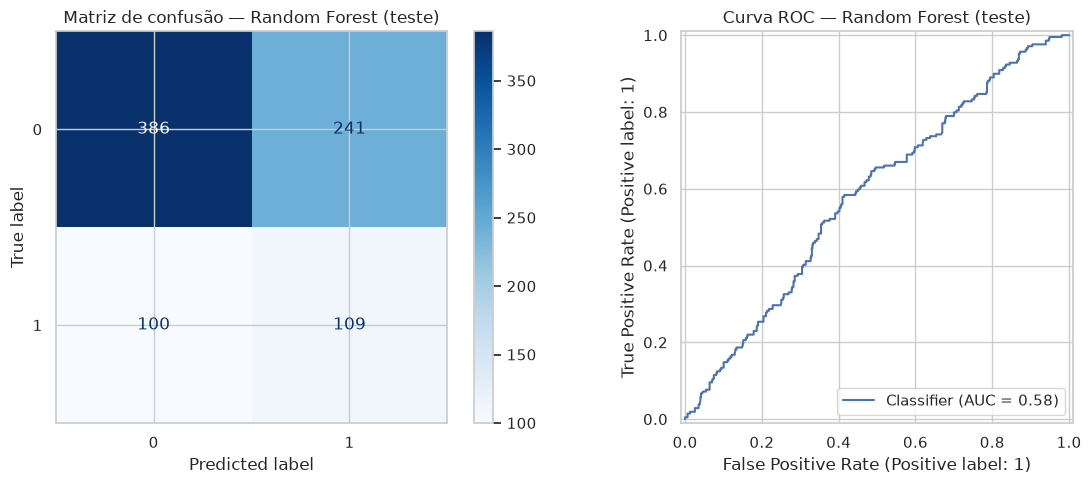

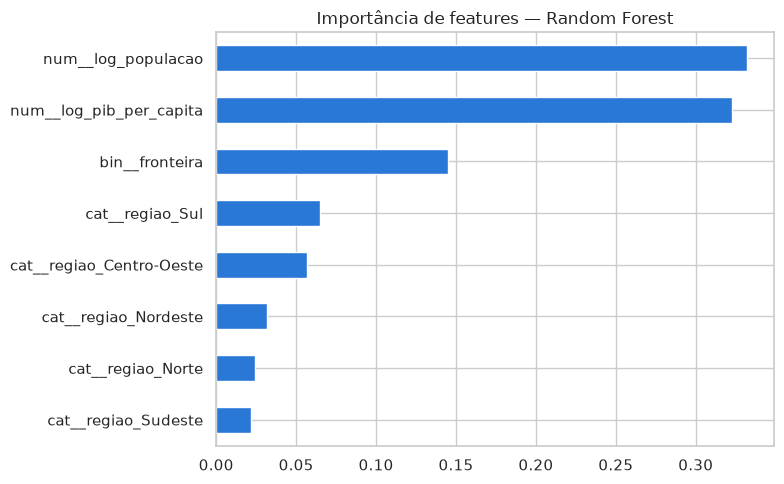

In [6]:
melhor_modelo = modelos_ajustados[nome_melhor]

pred_teste = melhor_modelo.predict(X_teste)
proba_teste = melhor_modelo.predict_proba(X_teste)[:, 1]
f1_teste = f1_score(y_teste, pred_teste)
roc_auc_teste = roc_auc_score(y_teste, proba_teste)
print(f"{nome_melhor} no teste — F1: {f1_teste:.3f} | ROC-AUC: {roc_auc_teste:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Matriz de confusão — {nome_melhor} (teste)")
RocCurveDisplay.from_predictions(y_teste, proba_teste, ax=axes[1])
axes[1].set_title(f"Curva ROC — {nome_melhor} (teste)")
plt.tight_layout()
plt.savefig("../reports/matriz_confusao_roc.png", dpi=150, bbox_inches="tight")
plt.show()


def nomes_features_pos_preprocessamento(pipeline):
    return pipeline.named_steps["preprocessador"].get_feature_names_out()


modelo_final = melhor_modelo.named_steps["modelo"]
nomes_features = nomes_features_pos_preprocessamento(melhor_modelo)

if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(modelo_final.feature_importances_, index=nomes_features).sort_values(ascending=False)
    titulo_importancia = f"Importância de features — {nome_melhor}"
elif hasattr(modelo_final, "coef_"):
    importancias = pd.Series(modelo_final.coef_[0], index=nomes_features).abs().sort_values(ascending=False)
    titulo_importancia = f"|Coeficiente| — {nome_melhor} (proxy de importância)"
else:
    importancias = None

if importancias is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    importancias.head(10).sort_values().plot.barh(ax=ax, color="#2a78d6")
    ax.set_title(titulo_importancia)
    plt.tight_layout()
    plt.savefig("../reports/importancia_features.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"{nome_melhor} (KNN) não tem importância de feature nativa nem coeficientes lineares.")


## 6. Checagem de overfitting

Sinal clássico de overfitting (citado explicitamente pela disciplina):
resultado ótimo no treino e ruim fora dele. Comparamos o F1 de cada
modelo no treino contra o F1 na validação (já calculado na seção 4).

In [7]:
def _interpretar_gap(gap: float) -> str:
    # abs(gap), não gap: um gap bem negativo (validação bem melhor que treino) não
    # é "pequeno" só porque é negativo — é tão atípico quanto um gap positivo grande,
    # só que na direção oposta (ver nota abaixo).
    magnitude = abs(gap)
    if magnitude < 0.05:
        return "gap pequeno — não sugere overfitting relevante"
    if gap > 0 and magnitude < 0.15:
        return "gap moderado — leve indício de overfitting, vale acompanhar"
    if gap > 0:
        return "gap grande — sinal de overfitting (o modelo memorizou padrões do treino que não generalizam)"
    return (
        "gap negativo e grande — validação bem melhor que treino, o que não é "
        "overfitting, mas também não é o padrão esperado; mais provável ser "
        "variância de amostra pequena do que um sinal de qualidade do modelo"
    )


tabela_comparacao_idx = tabela_comparacao.set_index("modelo")
linhas_overfitting = []
for nome, modelo in modelos_ajustados.items():
    f1_treino_modelo = f1_score(y_treino, modelo.predict(X_treino))
    f1_val_modelo = tabela_comparacao_idx.loc[nome, "f1"]
    gap = f1_treino_modelo - f1_val_modelo
    linhas_overfitting.append({"modelo": nome, "f1_treino": f1_treino_modelo, "f1_validacao": f1_val_modelo, "gap": gap})
    print(f"{nome}: F1 treino={f1_treino_modelo:.3f} | F1 validação={f1_val_modelo:.3f} | {_interpretar_gap(gap)}")

tabela_overfitting = pd.DataFrame(linhas_overfitting).sort_values("gap", ascending=False)
display(tabela_overfitting)


Regressão Logística: F1 treino=0.415 | F1 validação=0.450 | gap pequeno — não sugere overfitting relevante
KNN: F1 treino=0.445 | F1 validação=0.236 | gap grande — sinal de overfitting (o modelo memorizou padrões do treino que não generalizam)
Random Forest: F1 treino=0.445 | F1 validação=0.452 | gap pequeno — não sugere overfitting relevante
XGBoost: F1 treino=0.517 | F1 validação=0.434 | gap moderado — leve indício de overfitting, vale acompanhar


,modelo,f1_treino,f1_validacao,gap
1,KNN,0.444596,0.236025,0.208571
3,XGBoost,0.516761,0.434164,0.082597
2,Random Forest,0.444606,0.452381,-0.007775
0,Regressão Logística,0.414935,0.449568,-0.034632


## 7. Clusterização (K-Means): segmentação por perfil

Além de classificar risco, o README também promete segmentar
municípios por perfil de cobertura e características socioeconômicas —
um problema não-supervisionado, então não usa o alvo `baixa_cobertura`
nem o split da seção 2 (K-Means não tem "resposta certa" para
validar). Usamos as três variáveis mais diretamente relacionadas ao
objetivo de negócio (população, PIB per capita e a própria cobertura,
todas padronizadas — K-Means é sensível à escala), escolhendo o número
de clusters *k* pelo método do cotovelo (inércia) combinado com o
silhouette score, e não só por inspeção visual do cotovelo.

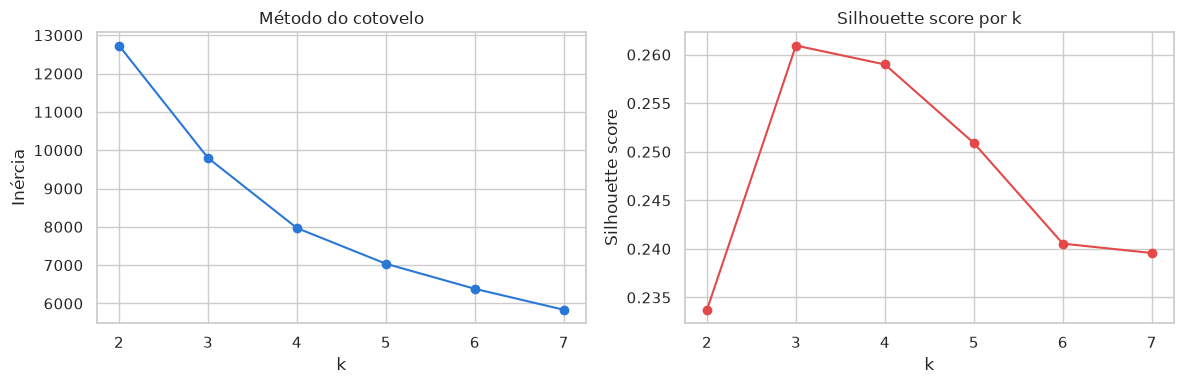

k escolhido (maior silhouette score): 3


,n_municipios,cobertura_media,populacao_mediana,pib_per_capita_medio,pct_fronteira
cluster,,,,,
0,2278,75.57,11551.5,18797.41,0.13
1,1198,80.99,52338.0,57686.47,0.36
2,2094,95.61,5709.0,50354.93,0.48


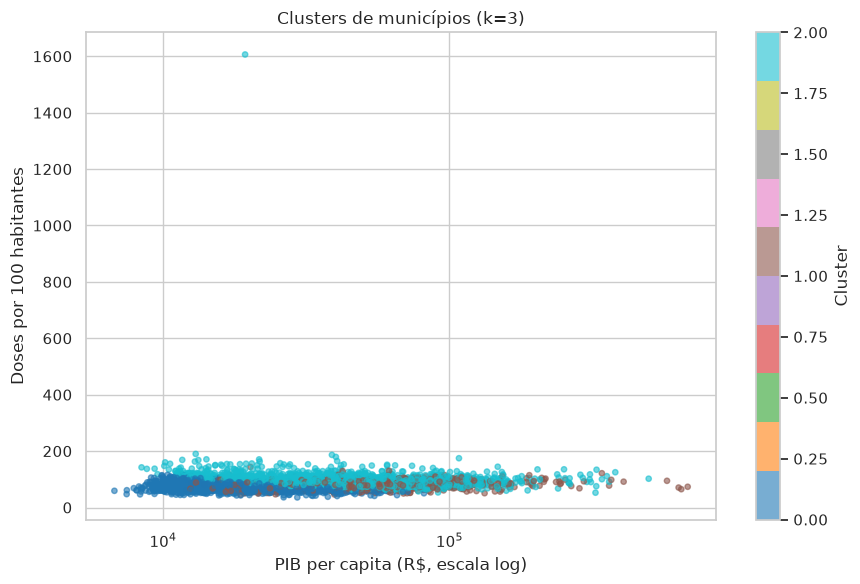


Cluster 0 é o de menor cobertura média (75.6 doses/100 hab.), com 2278 municípios, população mediana de 11.551 habitantes e PIB per capita médio de R$ 18.797 — candidato natural a prioridade em campanhas de imunização.

Cluster 2 é o de maior cobertura média (95.6 doses/100 hab.), com 2094 municípios, população mediana de 5.709 habitantes e PIB per capita médio de R$ 50.355.
Atenção: este é também o cluster de menor população mediana entre os 3 — a seção 5 do notebook 02 já mostrou que municípios pequenos têm métrica de cobertura mais volátil (poucas doses já mudam bastante o percentual). A cobertura mais alta deste cluster pode ser, em parte, esse efeito de volatilidade, não necessariamente melhor acesso real à vacinação — vale investigar antes de tratar este cluster como referência de boa cobertura.


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURES_CLUSTER = ["log_populacao", "log_pib_per_capita", "cobertura_doses_por_100_habitantes"]
X_cluster = modelagem[FEATURES_CLUSTER].copy()
X_cluster["cobertura_doses_por_100_habitantes"] = np.log1p(X_cluster["cobertura_doses_por_100_habitantes"])

scaler_cluster = StandardScaler()
X_cluster_padronizado = scaler_cluster.fit_transform(X_cluster)

valores_k = range(2, 8)
inercias, silhuetas = [], []
for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_padronizado)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_cluster_padronizado, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(valores_k), inercias, marker="o", color="#2a78d6")
axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[1].plot(list(valores_k), silhuetas, marker="o", color="#e34948")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../reports/cotovelo_silhueta.png", dpi=150, bbox_inches="tight")
plt.show()

k_escolhido = list(valores_k)[int(np.argmax(silhuetas))]
print(f"k escolhido (maior silhouette score): {k_escolhido}")

kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
modelagem["cluster"] = kmeans_final.fit_predict(X_cluster_padronizado)

perfil_clusters = modelagem.groupby("cluster").agg(
    n_municipios=("codigo_municipio", "count"),
    cobertura_media=("cobertura_doses_por_100_habitantes", "mean"),
    populacao_mediana=("populacao", "median"),
    pib_per_capita_medio=("pib_per_capita_reais", "mean"),
    pct_fronteira=("fronteira", "mean"),
).round(2)
display(perfil_clusters)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    modelagem["pib_per_capita_reais"], modelagem["cobertura_doses_por_100_habitantes"],
    c=modelagem["cluster"], cmap="tab10", alpha=0.6, s=15,
)
ax.set_xscale("log")
ax.set_xlabel("PIB per capita (R$, escala log)")
ax.set_ylabel("Doses por 100 habitantes")
ax.set_title(f"Clusters de municípios (k={k_escolhido})")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../reports/clusters.png", dpi=150, bbox_inches="tight")
plt.show()

cluster_menor_cobertura = perfil_clusters["cobertura_media"].idxmin()
cluster_maior_cobertura = perfil_clusters["cobertura_media"].idxmax()
linha_menor = perfil_clusters.loc[cluster_menor_cobertura]
linha_maior = perfil_clusters.loc[cluster_maior_cobertura]

# separador de milhar no padrão BR (ponto), aplicado só aos números formatados,
# não à frase inteira — senão as vírgulas de pontuação também virariam ponto
populacao_fmt = f"{int(linha_menor['populacao_mediana']):,}".replace(",", ".")
pib_fmt = f"{linha_menor['pib_per_capita_medio']:,.0f}".replace(",", ".")

print(
    f"\nCluster {cluster_menor_cobertura} é o de menor cobertura média "
    f"({linha_menor['cobertura_media']:.1f} doses/100 hab.), com "
    f"{int(linha_menor['n_municipios'])} municípios, população mediana de "
    f"{populacao_fmt} habitantes e PIB per capita médio de R$ {pib_fmt} — "
    "candidato natural a prioridade em campanhas de imunização."
)

populacao_fmt_maior = f"{int(linha_maior['populacao_mediana']):,}".replace(",", ".")
pib_fmt_maior = f"{linha_maior['pib_per_capita_medio']:,.0f}".replace(",", ".")
print(
    f"\nCluster {cluster_maior_cobertura} é o de maior cobertura média "
    f"({linha_maior['cobertura_media']:.1f} doses/100 hab.), com "
    f"{int(linha_maior['n_municipios'])} municípios, população mediana de "
    f"{populacao_fmt_maior} habitantes e PIB per capita médio de R$ {pib_fmt_maior}."
)

if linha_maior["populacao_mediana"] == perfil_clusters["populacao_mediana"].min():
    print(
        "Atenção: este é também o cluster de menor população mediana entre os "
        f"{k_escolhido} — a seção 5 do notebook 02 já mostrou que municípios "
        "pequenos têm métrica de cobertura mais volátil (poucas doses já mudam "
        "bastante o percentual). A cobertura mais alta deste cluster pode ser, em "
        "parte, esse efeito de volatilidade, não necessariamente melhor acesso "
        "real à vacinação — vale investigar antes de tratar este cluster como "
        "referência de boa cobertura."
    )


## 8. Interpretação final

Fechando com as perguntas que a disciplina pede explicitamente:

**O modelo está sofrendo overfitting?** Ver a leitura por modelo na
seção 6 — o gap treino/validação de cada um já indica isso
diretamente; um gap grande é mais esperado em Random Forest e XGBoost
(mais flexíveis, mais propensos a se ajustar demais ao treino) do que
na Regressão Logística.

**O modelo generaliza bem?** A métrica de teste (seção 5) foi vista uma
única vez, depois de toda a escolha de modelo/hiperparâmetro já ter
sido feita só com treino e validação — se o F1 do teste ficar muito
distante do F1 de validação da seção 4, isso é sinal de que a validação
não estava representando bem o comportamento fora da amostra.

**O modelo possui viés?** Duas camadas de viés a considerar. A primeira
é a que já documentamos na Etapa 2
(`docs/criterios_selecao_dados.md`): o modelo usa PIB per capita como
única variável socioeconômica, e essa variável já mostrou ser um proxy
fraco e distorcido por concentração industrial (ex.: municípios-sede de
refinaria) — um modelo treinado sobre ela pode aprender esse mesmo
viés, não uma relação real com o acesso à vacinação. A segunda é o
próprio recorte de "fronteira por UF" (seção 1): é uma aproximação
grosseira que pode atribuir o mesmo risco geográfico a municípios muito
distantes da fronteira de fato.

**O modelo é explicável?** A Regressão Logística é diretamente
interpretável via coeficientes; Random Forest e XGBoost oferecem
importância de features (uma explicação agregada, não por predição
individual); o KNN é o menos explicável dos quatro — não há
coeficiente nem importância nativa, só a vizinhança usada em cada
previsão.

**Faz sentido para o negócio?** O objetivo declarado no início do
projeto (`docs/entendimento_problema.md`) é apoiar a priorização de
campanhas de imunização, não substituir o julgamento de um gestor de
saúde pública. Tanto a classificação (seção 5) quanto a clusterização
(seção 7) devem ser lidas como **apoio à decisão**: uma lista
priorizada de municípios para investigação e ação, não uma decisão
automática — sobretudo dado o viés potencial descrito acima.

## 9. Limitações e possíveis melhorias futuras

- **Escopo transversal, não temporal**: como registrado na introdução,
  este modelo classifica o perfil de risco *atual* dos municípios, não
  prevê o *futuro* — faltam dados de um segundo ano (PNI, IBGE e PIB)
  para treinar em ano N e validar em N+1, que seria a versão mais fiel
  ao objetivo original do projeto.
- **Fronteira aproximada por UF**: usar a lista oficial de municípios da
  faixa de fronteira (Lei 6.634/1979), em vez do estado inteiro, daria
  um sinal geográfico bem mais preciso.
- **Desbalanceamento tratado só por peso de classe**: `class_weight`/
  `scale_pos_weight` é a abordagem mais simples; técnicas de
  reamostragem (ex.: SMOTE) são uma melhoria possível, a testar com
  cautela para não gerar municípios sintéticos pouco realistas.
- **Custo computacional**: o Random Forest foi o modelo mais lento para
  ajustar nesta grade de hiperparâmetros — em um cenário com mais dados
  (ex.: granularidade mensal em vez de anual), o custo de re-treinar
  os quatro modelos cresceria de forma não-trivial.
- **Poucas features**: o dataset de modelagem tem só três variáveis
  numéricas de fato (população, PIB per capita, fronteira) além da
  região. A sazonalidade mensal identificada no notebook 02 (seção 7)
  não entrou como feature aqui porque o dataset `refined` usado nesta
  etapa é anual — incorporar o mês exigiria remodelar o pipeline de
  `refined` para preservar granularidade mensal por município, o que
  hoje não existe (ver `docs/decisoes_limpeza.md`, seção 2).